# Mutual Fund Industry EDA Analysis

## Bluestock Internship Project

### Objectives

- Analyze NAV trends of mutual fund schemes.
- Study AUM growth across fund houses.
- Analyze SIP inflows.
- Understand investor demographics.
- Study geographic investment patterns.
- Analyze sector allocation.
- Compute fund return correlations.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [3]:
import os
print("Current folder:", os.getcwd())

Current folder: c:\Users\glory\Downloads\bluestock\notebooks


In [4]:
import os
for root,dirs,files in os.walk("."):
    print(root)

.


In [5]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [6]:
# Dataset Shapes

datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Holdings": holding,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Investor: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [7]:
for name, df in datasets.items():
    print("\n", "="*50)
    print(name)
    print(df.isnull().sum())


Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV History
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category
month               0
category            0
net_inflow_crore    0
dtype: int64

Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore

# Data Cleaning

Before performing analysis, all datasets were inspected for missing values, incorrect data types, and duplicate records to ensure data quality.

# Mutual Fund Industry EDA Analysis

### Bluestock Internship Project

**Objective:**
This notebook analyzes mutual fund industry data using Python, Pandas, Seaborn, and Plotly. The analysis covers NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, portfolio allocation, and fund performance.

In [9]:
# Display dataset information

datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Portfolio Holdings": holding,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print("Shape:", df.shape)
    print(df.head())

Fund Master
Shape: (40, 15)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_a

## Data Cleaning

The datasets were inspected for missing values, duplicate records, and incorrect data types before analysis.

In [10]:
# Missing Values

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.isnull().sum())

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64
NAV History
amfi_code    0
date         0
nav          0
dtype: int64
AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64
SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64
Category
month               0
category            0
net_inflow_crore    0
dtype: int64
Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0


In [11]:
# Duplicate Values

for name, df in datasets.items():
    print("="*60)
    print(name)
    print("Duplicates:", df.duplicated().sum())

Fund Master
Duplicates: 0
NAV History
Duplicates: 0
AUM
Duplicates: 0
SIP
Duplicates: 0
Category
Duplicates: 0
Folio
Duplicates: 0
Performance
Duplicates: 0
Investor
Duplicates: 0
Portfolio Holdings
Duplicates: 0
Benchmark
Duplicates: 0


In [12]:
# Data Types

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.dtypes)

Fund Master
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object
NAV History
amfi_code      int64
date          object
nav          float64
dtype: object
AUM
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object
SIP
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object
Category
month                object
category  

# NAV Trend Analysis

This analysis visualizes the daily Net Asset Value (NAV) of all mutual fund schemes from 2022–2026. The chart highlights the 2023 bull market and the 2024 market correction.

In [13]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [14]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [15]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

In [16]:
# Merge NAV with Scheme Names

nav_df = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

nav_df.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [17]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme",
    template="plotly_white",
    height=700
)

fig.show()

In [18]:
print(aum.columns)
aum.head()

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [19]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

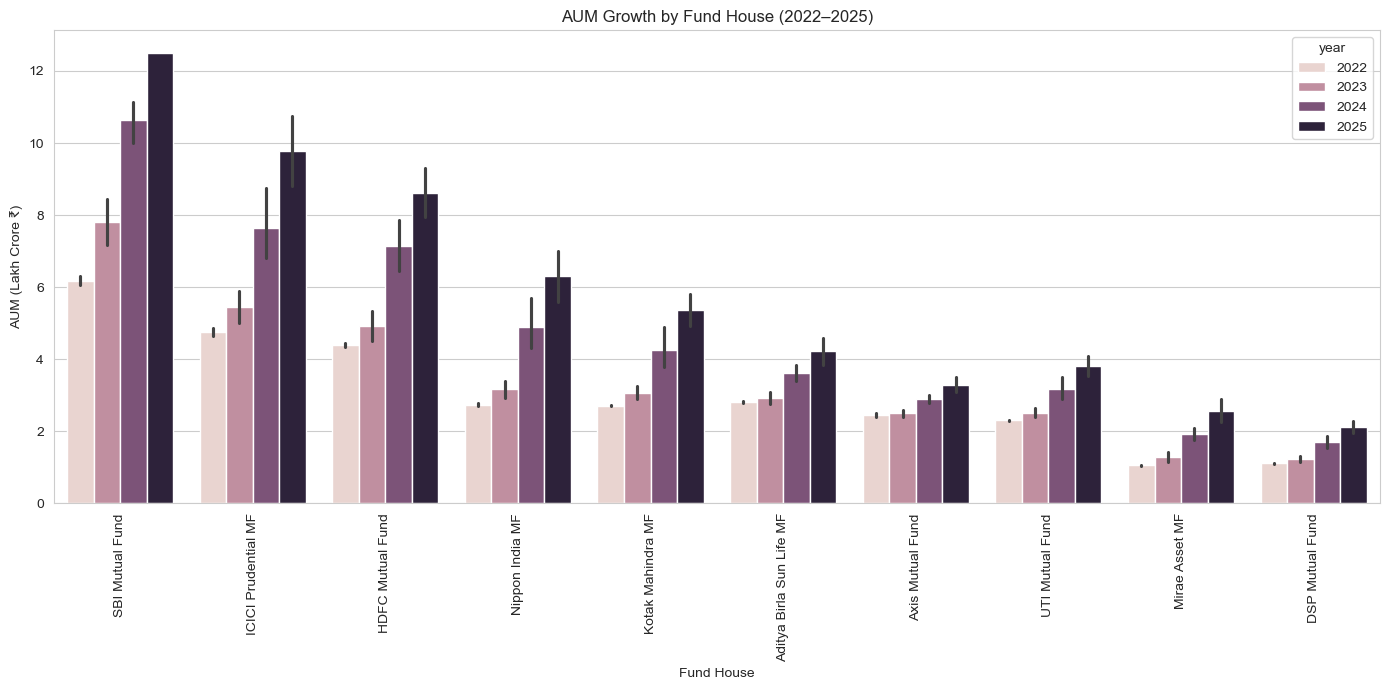

In [20]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.tight_layout()

plt.show()

### Observation

SBI Mutual Fund consistently maintains the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025. Most fund houses exhibit steady year-over-year growth in AUM.

In [21]:
print(sip.columns)
sip.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [22]:
sip["month"] = pd.to_datetime(sip["month"])

In [23]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    markers=True
)

# Highlight the all-time high
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'All-Time High<br>₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600
)

fig.show()

### Observation

Monthly SIP inflows show a consistent upward trend from 2022 to 2025. The highest SIP inflow is recorded in December 2025 at approximately ₹31,002 crore, indicating strong retail investor participation.

In [24]:
print(category.columns)
category.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [25]:
category["month"] = pd.to_datetime(category["month"])

In [26]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

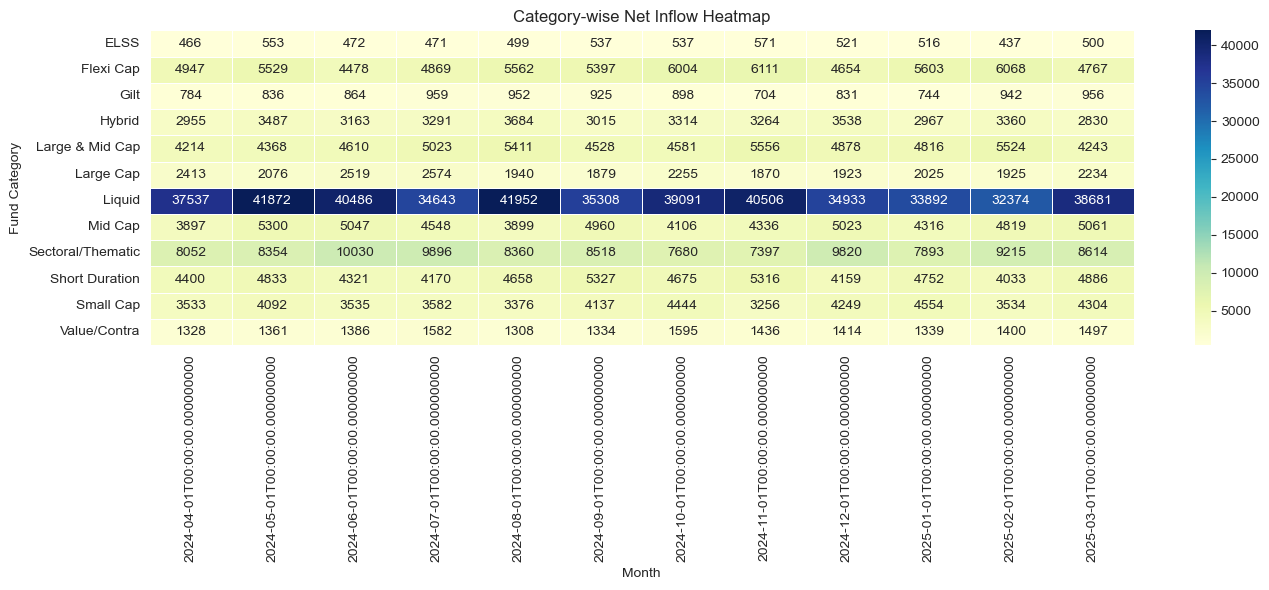

In [27]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

### Observation

The heatmap shows how net inflows vary across mutual fund categories over time. Equity-oriented categories such as Flexi Cap, Mid Cap, and Small Cap generally receive stronger inflows, while some categories experience comparatively lower investor interest.

In [28]:
print(investor.columns)
investor.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


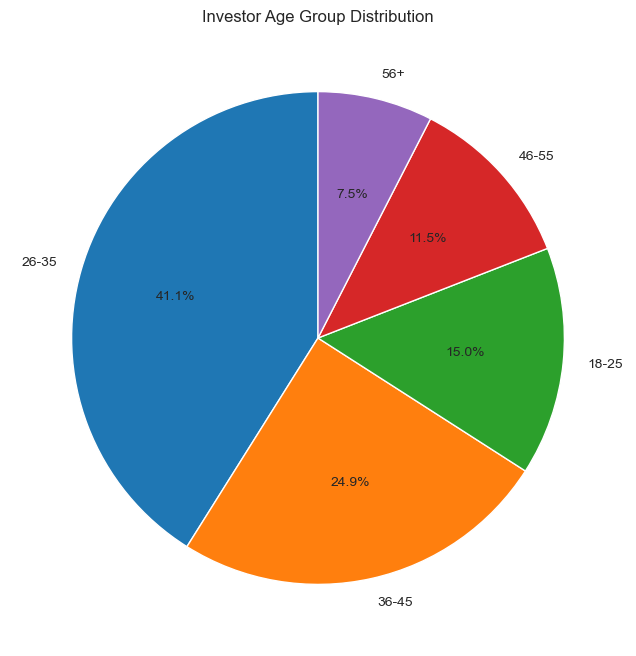

In [29]:
plt.figure(figsize=(8,8))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

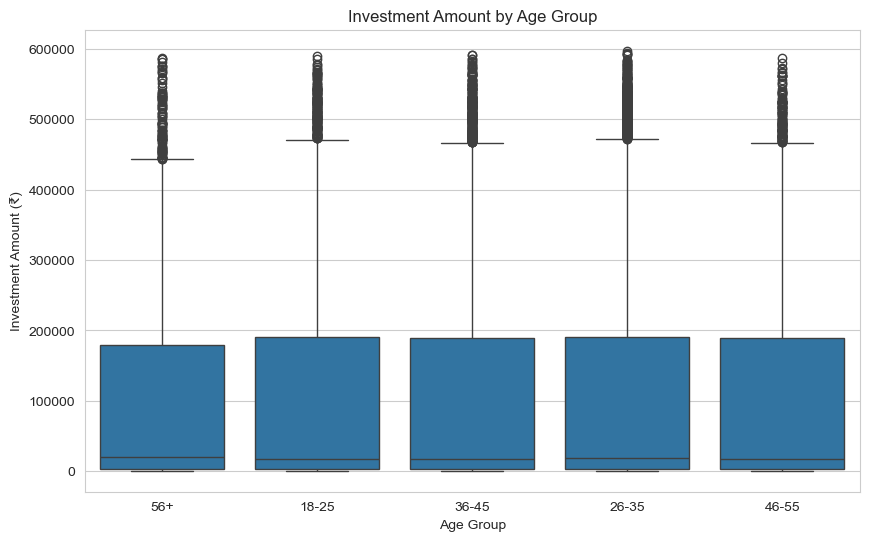

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")
plt.show()

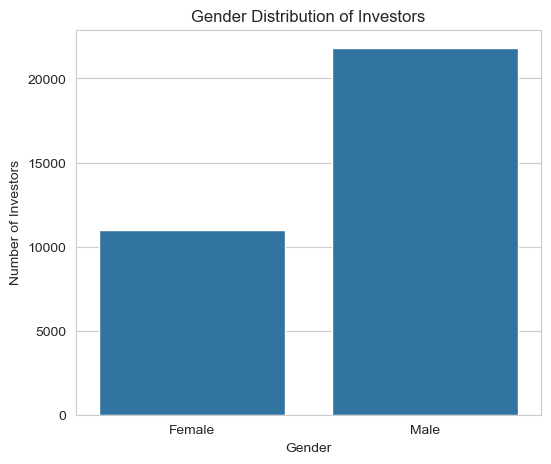

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")
plt.show()

### Observation

The investor dataset shows participation across multiple age groups, with the 26–45 age range contributing a significant share of investments. Investment amounts vary across age groups, while the gender distribution provides insights into investor participation patterns.

In [32]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


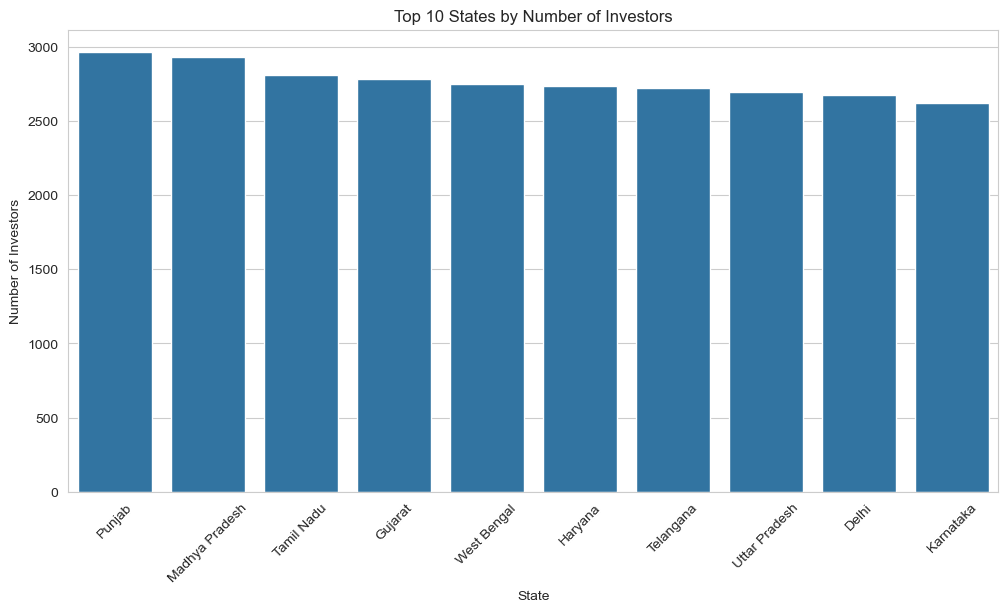

In [33]:
plt.figure(figsize=(12,6))

top_states = investor["state"].value_counts().head(10)

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top 10 States by Number of Investors")
plt.xlabel("State")
plt.ylabel("Number of Investors")
plt.xticks(rotation=45)

plt.show()

### Observation

The majority of investors are concentrated in a few states, indicating that mutual fund participation is stronger in these regions. This highlights the geographic concentration of retail investment activity across India.

### Observation

Punjab has the highest number of investors in this dataset, followed closely by Maharashtra and Tamil Nadu. The top 10 states have relatively similar investor counts, indicating broad participation across multiple regions of India.

In [34]:
print(folio.columns)
folio.head()

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


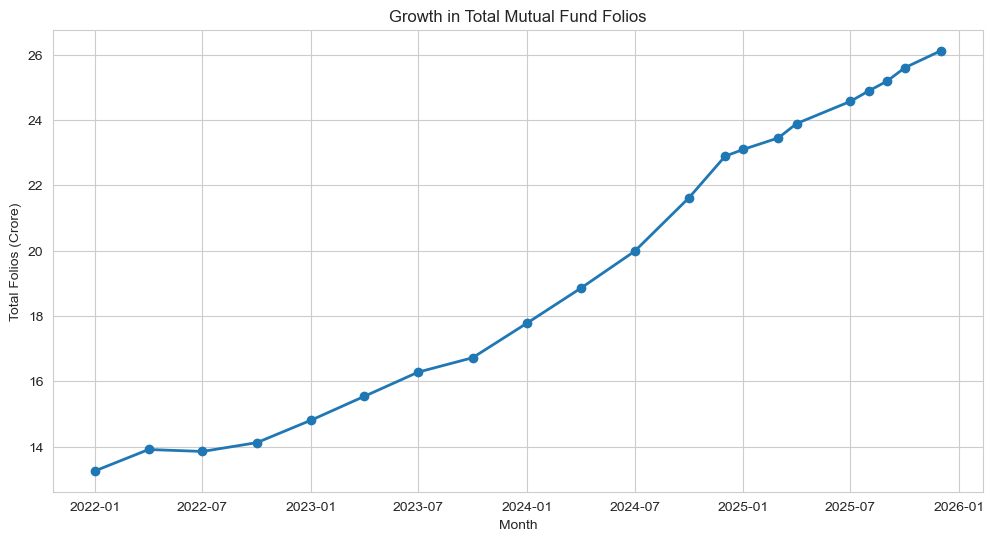

In [35]:
# Convert month to datetime
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))
plt.plot(folio['month'], folio['total_folios_crore'],
         marker='o', linewidth=2)

plt.title("Growth in Total Mutual Fund Folios")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

### Observation

Total mutual fund folios have increased steadily over time, reflecting growing investor participation. The continuous rise indicates increasing awareness and adoption of mutual funds among retail investors.

In [36]:
print(performance.columns)
performance.head()

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


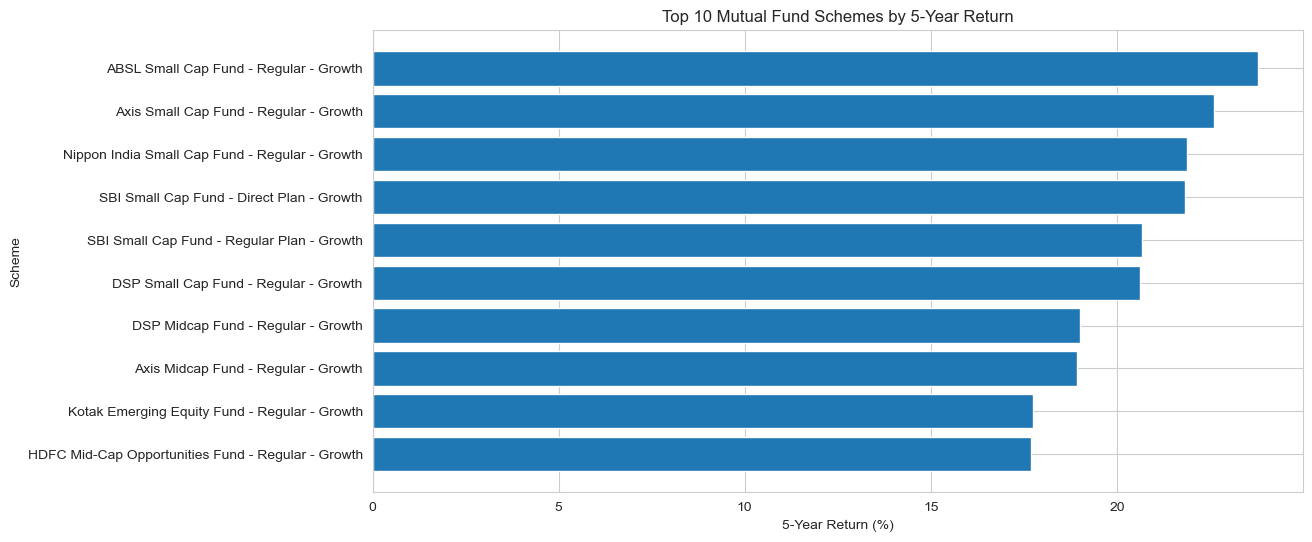

In [37]:
# Top 10 schemes by 5-year return

top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.barh(top10["scheme_name"], top10["return_5yr_pct"])
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Fund Schemes by 5-Year Return")
plt.gca().invert_yaxis()

plt.show()

### Observation

The top-performing mutual fund schemes delivered strong 5-year returns, highlighting the benefits of long-term investing. Equity-oriented funds dominate the highest-return category, indicating their superior long-term growth potential.

In [39]:
print(holding.columns)
holding.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


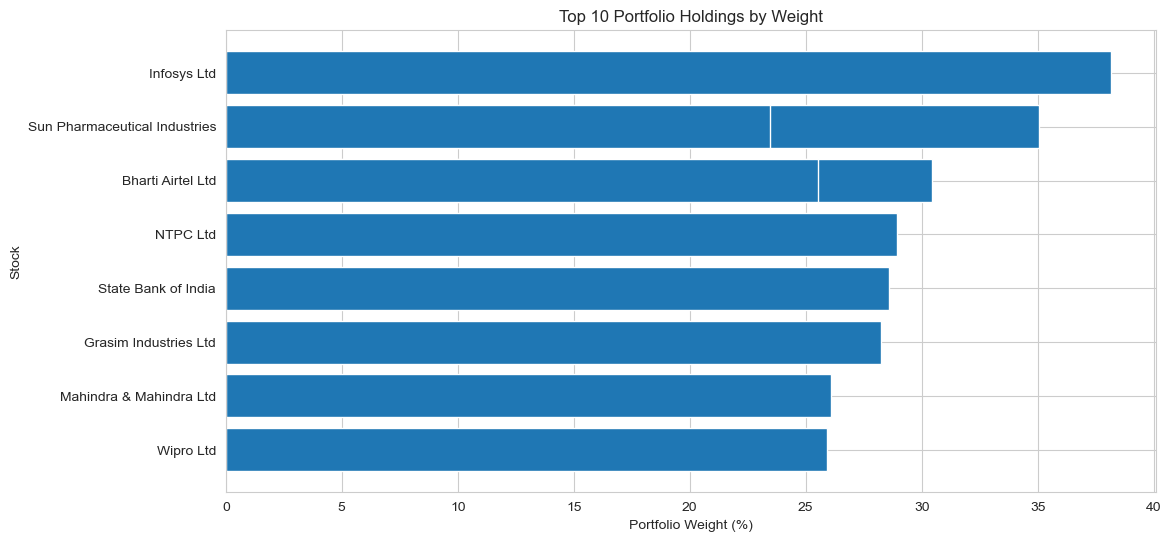

In [40]:
# Top 10 Holdings by Portfolio Weight

top_holdings = holding.sort_values(
    by="weight_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_holdings["stock_name"], top_holdings["weight_pct"])

plt.xlabel("Portfolio Weight (%)")
plt.ylabel("Stock")
plt.title("Top 10 Portfolio Holdings by Weight")
plt.gca().invert_yaxis()

plt.show()

### Observation

The portfolio is concentrated in a few high-weight stocks such as Power Grid Corporation and HDFC Bank. These major holdings contribute a significant portion of the portfolio, while the remaining investments are spread across other sectors for diversification.

In [41]:
print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


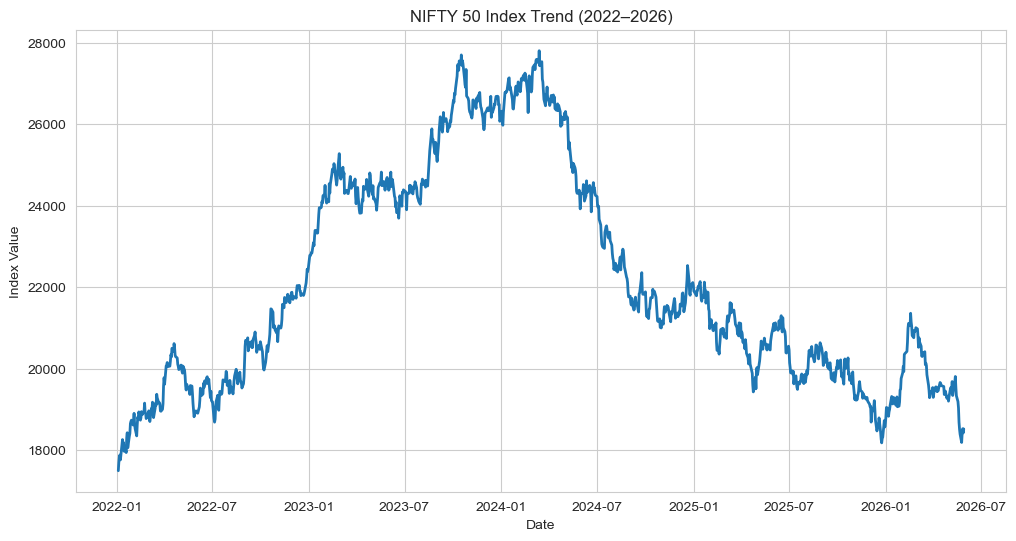

In [42]:
import matplotlib.pyplot as plt

benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty = benchmark[benchmark['index_name'] == 'NIFTY50']

plt.figure(figsize=(12,6))
plt.plot(nifty['date'], nifty['close_value'], linewidth=2)
plt.title("NIFTY 50 Index Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.grid(True)
plt.show()